# TNG100 domain shift -- 4-method run (No-DA, SIDDA, SIDDA + OT-reweight, SIDDA + Loss-reweight), with pulls and timing

Trimmed variant of `domain_shift_tng100_noda_mmd.ipynb`: same overlap-restricted
FIREbox <-> TNG100 data pipeline and heteroscedastic (mean, variance) GNN head,
but only 4 of the 6 methods (drops `MMD` and `SIDDA + Both`):

- **No-DA** -- source-only baseline, no adaptation
- **SIDDA** -- diffusion-based domain alignment, no reweighting
- **SIDDA + OT-reweight** -- adds optimal-transport-based sample reweighting
- **SIDDA + Loss-reweight** -- adds per-sample loss reweighting (this was called
  `CE-reweight` in the 6-method notebook, a name carried over from SIDDA's
  classification setting where it reweights the cross-entropy loss; since this
  is regression, it's renamed `Loss-reweight` here and in every plot label)

Each of the 4 methods is trained once per direction (`FIREbox -> TNG100`,
`TNG100 -> FIREbox`) with wall-clock time recorded per run. Training happens
on whatever device `shiftkit`'s trainers auto-select (`cuda` if available --
see the device print in the setup cell below).

After training: a comparison table (RMSE, R^2, mean relative error `eps`, and
reduced `chi^2` from the model's own predicted uncertainty), predicted-vs-true
scatter plots with per-node error bars, pull histograms
(`pull = (pred_mean - true) / pred_std`, the same quantity the `chi^2` column
summarizes as `mean(pull**2)`), and an Isomap view of each method's latent
space.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / "scripts").exists() and (candidate / "data").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate repository root containing 'scripts' and 'data'.")

SCRIPTS_DIR = REPO_ROOT / "scripts"
DM_ROOT = REPO_ROOT / "data"
SHIFTKIT_DIR = REPO_ROOT / "ShiftKit"

for path in [str(REPO_ROOT), str(SCRIPTS_DIR), str(DM_ROOT), str(SHIFTKIT_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from process_data import DataProcessor, sample_pyg_subgraph
from process_tng_data import TNGDataProcessor

OUTPUT_DIR = REPO_ROOT / "output" / "domain-shift-tng100"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "fire_path": DM_ROOT / "firebox_data" / "FIREbox_z=0.txt",
    "tng_path": DM_ROOT / "tng-data" / "TNG100" / "subhalos_99.parquet",
    "r": 1,
    "test_size": 0.1,
    "val_size": 0.1,
    "standardize": True,
    "stratify_bins": 10,
    "random_state": 42,
    "upper_mass": 12,
}
GRAPH_KWARGS = dict(
    r=CONFIG["r"], test_size=CONFIG["test_size"], val_size=CONFIG["val_size"],
    standardize=CONFIG["standardize"], stratify_bins=CONFIG["stratify_bins"],
    random_state=CONFIG["random_state"], upper_mass=CONFIG["upper_mass"],
)

print(f"Repo: {REPO_ROOT}")
print(f"TNG100 source file: {CONFIG['tng_path'].name}")
print(f"CUDA available: {torch.cuda.is_available()}"
      + (f"  ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))


Repo: D:\Minerva\Senior Year\Capstone\DM_FIREbox_notebook_created_snapshot
TNG100 source file: subhalos_99.parquet
CUDA available: True  (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


## Load both domains and build overlap-restricted subgraphs

Identical to `domain_shift_tng100_noda_mmd.ipynb`: both domains use
`subhalos="both"`, TNG100 is pre-subsampled to keep the radius-graph edge
count tractable, and both graphs are then restricted to the shared
`lg_Mstar` overlap range via `induced_subgraph_by_mask` (intersecting with
the existing stratified train/val/test masks rather than re-splitting).

In [9]:
fire_proc = DataProcessor(file_path=str(CONFIG["fire_path"]), subhalos="both")
fire_data = fire_proc.create_graph_data(**GRAPH_KWARGS)

tng_proc = TNGDataProcessor(file_path=str(CONFIG["tng_path"]), subhalos="both")

MAX_TNG_ROWS_FOR_GRAPH = 7500
if len(tng_proc.df_filtered) > MAX_TNG_ROWS_FOR_GRAPH:
    rng_pre = np.random.default_rng(CONFIG["random_state"])
    keep_idx = np.sort(rng_pre.choice(len(tng_proc.df_filtered), size=MAX_TNG_ROWS_FOR_GRAPH, replace=False))
    print(f"Pre-subsampling TNG100 catalog: {len(tng_proc.df_filtered):,} -> {MAX_TNG_ROWS_FOR_GRAPH:,} rows "
          f"(before graph construction, to keep radius-graph edge count tractable)")
    tng_proc.df_filtered = tng_proc.df_filtered.iloc[keep_idx].reset_index(drop=True)

tng_data = tng_proc.create_graph_data(**GRAPH_KWARGS)
tng_subgraph = sample_pyg_subgraph(tng_data, num_nodes_sample=fire_data.num_nodes, random_state=CONFIG["random_state"])

FIRE_MSTAR_COL = "lg_Mstar_<Rhalo"
TNG_MSTAR_COL = "stellar_mass"
fdf = fire_proc.df_filtered
tdf_full = tng_proc.df_filtered
fire_mstar = fdf[FIRE_MSTAR_COL].values.astype(float)
tng_mstar = tdf_full[TNG_MSTAR_COL].values.astype(float)
overlap_lo, overlap_hi = tng_mstar.min(), fire_mstar.max()
print(f"Overlap range: [{overlap_lo:.2f}, {overlap_hi:.2f}] dex in lg_Mstar")

import torch
from torch_geometric.data import Data


def induced_subgraph_by_mask(data, keep_mask):
    '''Induced subgraph over nodes where keep_mask is True.'''
    keep_idx = keep_mask.nonzero(as_tuple=False).view(-1)
    index_map = {int(old): new for new, old in enumerate(keep_idx.tolist())}
    keep_set = set(keep_idx.tolist())

    edge_index = data.edge_index
    src, dst = edge_index[0].tolist(), edge_index[1].tolist()
    edge_mask = torch.tensor([s in keep_set and d in keep_set for s, d in zip(src, dst)], dtype=torch.bool)
    kept_edges = edge_index[:, edge_mask]
    remapped = torch.stack([
        torch.tensor([index_map[int(s)] for s in kept_edges[0].tolist()], dtype=torch.long),
        torch.tensor([index_map[int(d)] for d in kept_edges[1].tolist()], dtype=torch.long),
    ])

    sub = Data(
        x=data.x[keep_idx],
        edge_index=remapped,
        y=data.y[keep_idx],
        pos=data.pos[keep_idx] if getattr(data, "pos", None) is not None else None,
    )
    for split in ("train_mask", "val_mask", "test_mask"):
        if hasattr(data, split):
            setattr(sub, split, getattr(data, split)[keep_idx])
    return sub


fire_keep = torch.tensor((fdf[FIRE_MSTAR_COL].values >= overlap_lo) & (fdf[FIRE_MSTAR_COL].values <= overlap_hi))
tng_keep = torch.tensor((tdf_full[TNG_MSTAR_COL].values >= overlap_lo) & (tdf_full[TNG_MSTAR_COL].values <= overlap_hi))

fire_overlap_graph = induced_subgraph_by_mask(fire_data, fire_keep)
tng_overlap_full_graph = induced_subgraph_by_mask(tng_data, tng_keep)
tng_overlap_graph = tng_overlap_full_graph  # Use the full overlap graph for TNG100, without size-matching
# tng_overlap_graph = sample_pyg_subgraph(
#     tng_overlap_full_graph, num_nodes_sample=fire_overlap_graph.num_nodes, random_state=CONFIG["random_state"]
# )

for name, d in [
    ("FIREbox (overlap)", fire_overlap_graph),
    ("TNG100 (overlap, size-matched)", tng_overlap_graph),
]:
    print(f"{name:32s} nodes={d.num_nodes:,}  edges={d.num_edges:,}  "
          f"train={int(d.train_mask.sum())}  val={int(d.val_mask.sum())}  test={int(d.test_mask.sum())}")

DIRECTIONS = {
    "tng_to_fire": dict(src=tng_overlap_graph, tgt=fire_overlap_graph, src_name="TNG100", tgt_name="FIREbox")
}


Max lg_Mhalo: 11.941
Pre-subsampling TNG100 catalog: 56,427 -> 7,500 rows (before graph construction, to keep radius-graph edge count tractable)
Overlap range: [7.70, 11.08] dex in lg_Mstar
FIREbox (overlap)                nodes=1,035  edges=161,682  train=818  val=110  test=107
TNG100 (overlap, size-matched)   nodes=7,228  edges=5,795,772  train=5782  val=722  test=724


## Train 4 methods, both directions, on CUDA

Same hyperparameters as the 6-method notebook (`hidden_channels=64,
num_layers=2, SAGE`, `EPOCHS=150, WARMUP=10, LR=5e-3`) for a like-for-like
comparison. `shiftkit`'s trainers auto-select `cuda` internally
(`shiftkit.methods.mmd._auto_device`) and `shiftkit.models.GNN` does the same
for the bare model, so nothing extra is needed to put this on GPU beyond
having a CUDA-enabled `torch` installed -- confirmed in the setup cell above.

Wall-clock time for each individual `trainer.fit(epochs=EPOCHS)` call (i.e.
one run = one method x one direction) is recorded into `elapsed_all` and
logged to `overlap_{direction}_progress.log`.

In [20]:
import json
import time

from shiftkit import (
    GNN, DataManager,
    SourceOnlyGaussianRegressionTrainer, SIDDAGaussianRegressionTrainer,
)

MODEL_CONFIG = {"hidden_channels": 64, "num_layers": 2, "model_name": "SAGE"}
EPOCHS = 200
WARMUP = 10
LR = 5e-3

# Only 4 of the 6 methods from the full comparison: No-DA and the 3 SIDDA
# variants that do NOT combine both reweighting schemes at once.
# "CE-reweight" (SIDDA's classification-era name for potential-based
# reweighting) is renamed "Loss-reweight" here since this task is regression.
METHOD_SPECS = [
    dict(label="No-DA",                    kind="sourceonly"),
    dict(label="SIDDA",                    kind="sidda", use_potentials=False, weight_ot=False),
    dict(label="SIDDA + OT-reweight",      kind="sidda", use_potentials=False, weight_ot=True),
    dict(label="SIDDA + Loss-reweight",    kind="sidda", use_potentials=True,  weight_ot=False),
]
ALL_METHOD_ORDER = [m["label"] for m in METHOD_SPECS]


def merge_json(path, new_entries):
    '''Load-merge-save: preserve existing entries, add new ones.'''
    existing = {}
    if path.exists():
        with open(path) as f:
            existing = json.load(f)
    existing.update(new_entries)
    with open(path, "w") as f:
        json.dump(existing, f)
    return existing


def build_trainer(spec, model, train_src, train_tgt):
    if spec["kind"] == "sourceonly":
        return SourceOnlyGaussianRegressionTrainer(model, train_src, train_tgt, lr=LR)
    if spec["kind"] == "sidda":
        return SIDDAGaussianRegressionTrainer(
            model, train_src, train_tgt, lr=LR, warmup_epochs=WARMUP,
            use_potentials=spec["use_potentials"], weight_ot=spec["weight_ot"],
            potential_temperature=0.5, ot_ema_momentum=0.9,
        )
    raise ValueError(spec["kind"])


trainers_all = {}      # {direction: {label: trainer}}
histories_all = {}     # {direction: {label: history}}
results_all = {}       # {direction: {label: {"src":..., "tgt":...}}}
predictions_all = {}   # {direction: {label: {"src": (true,mean,std), "tgt": (true,mean,std)}}}
elapsed_all = {}        # {direction: {label: seconds}}

for direction, spec in DIRECTIONS.items():
    src, tgt = spec["src"], spec["tgt"]
    ckpt_dir = OUTPUT_DIR / f"checkpoints_overlap_{direction}_4methods"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    progress_log = OUTPUT_DIR / f"overlap_{direction}_4methods_progress.log"

    def log_progress(msg):
        line = f"[{time.strftime('%H:%M:%S')}] {msg}"
        print(line)
        with open(progress_log, "a") as f:
            f.write(line + "\n")

    dm = DataManager(batch_size=1, num_workers=0)
    train_src, train_tgt = dm.load("pyg_domains", train=True, source=src, target=tgt)
    test_src, test_tgt = dm.load("pyg_domains", train=False, source=src, target=tgt)

    trainers_all[direction] = {}
    histories_all[direction] = {}
    results_all[direction] = {}
    predictions_all[direction] = {}
    elapsed_all[direction] = {}

    for method_spec in METHOD_SPECS:
        label = method_spec["label"]
        log_progress(f"{direction} | {label} : starting")

        model = GNN(
            src, MODEL_CONFIG["model_name"],
            hidden_channels=MODEL_CONFIG["hidden_channels"],
            num_layers=MODEL_CONFIG["num_layers"],
            regress=True, pool="none", predict_var=True,
        )
        log_progress(f"{direction} | {label} : model on {model.device}")
        trainer = build_trainer(method_spec, model, train_src, train_tgt)

        t0 = time.time()
        histories_all[direction][label] = trainer.fit(epochs=EPOCHS)
        elapsed = time.time() - t0
        elapsed_all[direction][label] = elapsed
        trainers_all[direction][label] = trainer

        r_src = trainer.evaluate(test_src, domain="source")
        r_tgt = trainer.evaluate(test_tgt, domain="target")
        results_all[direction][label] = {"src": r_src, "tgt": r_tgt}

        true_src, mean_src, std_src = trainer.predict(test_src)
        true_tgt, mean_tgt, std_tgt = trainer.predict(test_tgt)
        predictions_all[direction][label] = {
            "src": (true_src, mean_src, std_src),
            "tgt": (true_tgt, mean_tgt, std_tgt),
        }
        np.savez(
            ckpt_dir / f"{label.replace(' ', '_')}_predictions.npz",
            true_src=true_src, mean_src=mean_src, std_src=std_src,
            true_tgt=true_tgt, mean_tgt=mean_tgt, std_tgt=std_tgt,
        )

        log_progress(
            f"{direction} | {label} : done in {elapsed:6.1f}s  "
            f"src RMSE={r_src['rmse']:.4f}  R2={r_src['r2']:.3f}  |  "
            f"tgt RMSE={r_tgt['rmse']:.4f}  R2={r_tgt['r2']:.3f}"
        )

        torch.save(model.state_dict(), ckpt_dir / f"{label.replace(' ', '_')}.pt")
        merge_json(ckpt_dir / "histories.json", {label: histories_all[direction][label]})
        merge_json(ckpt_dir / "results.json", {label: results_all[direction][label]})
        merge_json(ckpt_dir / "elapsed_seconds.json", {label: elapsed})

    log_progress(f"=== direction {direction} complete ===")


[22:19:19] tng_to_fire | No-DA : starting
[22:19:19] tng_to_fire | No-DA : model on cuda


[  1/200]  L1=4.7571  L2=9.5239  SrcRMSE=10.7894  TgtRMSE=9.6828


[  2/200]  L1=4.5909  L2=9.1902  SrcRMSE=9.9291  TgtRMSE=8.8636


[  3/200]  L1=4.4161  L2=8.8321  SrcRMSE=9.0980  TgtRMSE=8.0120


[  4/200]  L1=4.2196  L2=8.4152  SrcRMSE=8.2466  TgtRMSE=7.1007


...

[196/200] [SIDDA ]  L1=7.5052  L2=5.7927  DA=0.0009  eta1=1.638  eta2=0.409  sigma=0.1107  Total=2.0864  SrcRMSE=0.5607  TgtRMSE=0.3232


[197/200] [SIDDA ]  L1=7.1125  L2=5.7754  DA=0.0009  eta1=1.640  eta2=0.410  sigma=0.1111  Total=2.0056  SrcRMSE=0.4607  TgtRMSE=0.3408


[198/200] [SIDDA ]  L1=6.7496  L2=5.9567  DA=0.0009  eta1=1.642  eta2=0.411  sigma=0.1112  Total=1.9679  SrcRMSE=0.3843  TgtRMSE=0.4022


[199/200] [SIDDA ]  L1=6.6528  L2=5.5843  DA=0.0009  eta1=1.645  eta2=0.411  sigma=0.1110  Total=1.8770  SrcRMSE=0.3661  TgtRMSE=0.3756


[200/200] [SIDDA ]  L1=6.7483  L2=5.3137  DA=0.0008  eta1=1.647  eta2=0.412  sigma=0.1106  Total=1.8410  SrcRMSE=0.3840  TgtRMSE=0.3407
[22:25:22] tng_to_fire | SIDDA + Loss-reweight : done in   88.6s  src RMSE=0.4286  R2=0.335  |  tgt RMSE=0.3446  R2=0.509
[22:25:22] === direction tng_to_fire complete ===


## Comparison table: RMSE, R^2, mean relative error (eps), reduced chi^2, and wall-clock time

`eps = mean(|true - pred_mean| / true)` and `chi2 = mean(pull**2)` where
`pull = (pred_mean - true) / pred_std` -- the same quantity histogrammed
below. `chi2` close to 1 means the model's predicted uncertainties are
well-calibrated on average (see the pull-histogram discussion above for the
caveat that `chi2 = mu_pull**2 + sigma_pull**2`, so it can't on its own
distinguish a biased-but-tight model from an unbiased-but-loose one).

In [21]:
def compute_eps_chi2(true, mean, std):
    eps = float(np.mean(np.abs(true - mean) / np.abs(true)))
    pulls = (mean - true) / std
    chi2 = float(np.mean(pulls ** 2))
    return eps, chi2, pulls


summaries = {}
for direction in DIRECTIONS:
    rows = []
    for label in ALL_METHOD_ORDER:
        r = results_all[direction][label]
        preds = predictions_all[direction][label]
        row = {"direction": direction, "variant": label, "elapsed_s": elapsed_all[direction][label]}
        for domain, key in [("src", "src"), ("tgt", "tgt")]:
            true, mean, std = preds[domain]
            eps, chi2, _ = compute_eps_chi2(true, mean, std)
            row[f"{key}_rmse"] = r[domain]["rmse"]
            row[f"{key}_r2"] = r[domain]["r2"]
            row[f"{key}_eps"] = eps
            row[f"{key}_chi2"] = chi2
            row[f"n_{key}"] = r[domain]["n_samples"]
        rows.append(row)
    summary = pd.DataFrame(rows)
    summary_path = OUTPUT_DIR / f"tng100_4methods_{direction}_summary.csv"
    summary.to_csv(summary_path, index=False)
    summaries[direction] = summary

    print(f"\n{direction}  (wall-clock in seconds)")
    print(f"{'Variant':<22} {'Time(s)':>8} {'SrcR2':>7} {'TgtR2':>7} {'SrcEps':>7} {'TgtEps':>7} {'SrcChi2':>8} {'TgtChi2':>8}")
    print("-" * 90)
    for _, r in summary.iterrows():
        print(f"{r['variant']:<22} {r['elapsed_s']:>8.1f} {r['src_r2']:>7.3f} {r['tgt_r2']:>7.3f} "
              f"{r['src_eps']:>7.3f} {r['tgt_eps']:>7.3f} {r['src_chi2']:>8.3f} {r['tgt_chi2']:>8.3f}")
    print(f"saved {summary_path}")

total_time = sum(v for d in elapsed_all.values() for v in d.values())
print(f"\nTotal wall-clock time across all runs: {total_time:.1f}s ({total_time/60:.1f} min)")



tng_to_fire  (wall-clock in seconds)
Variant                 Time(s)   SrcR2   TgtR2  SrcEps  TgtEps  SrcChi2  TgtChi2
------------------------------------------------------------------------------------------
No-DA                      29.8   0.114  -0.997   0.041   0.058    1.261    2.299
SIDDA                     152.9   0.404   0.419   0.033   0.030    0.897    0.736
SIDDA + OT-reweight        90.6   0.283   0.479   0.037   0.026    1.534    0.938
SIDDA + Loss-reweight      88.6   0.335   0.509   0.035   0.025    7.266    4.401
saved D:\Minerva\Senior Year\Capstone\DM_FIREbox_notebook_created_snapshot\output\domain-shift-tng100\tng100_4methods_tng_to_fire_summary.csv

Total wall-clock time across all runs: 361.9s (6.0 min)


## Predicted vs. true halo mass, with per-node error bars from the model's own predicted std

Uses `scripts/analysis/plot_style.py` for consistent styling across all 4
methods and both directions. Axis/column labels use the renamed
`SIDDA + Loss-reweight` label directly (it's the only name that ever appears
for that method in this notebook).

saved D:\Minerva\Senior Year\Capstone\DM_FIREbox_notebook_created_snapshot\output\domain-shift-tng100\tng100_4methods_tng_to_fire_pred_scatter.png


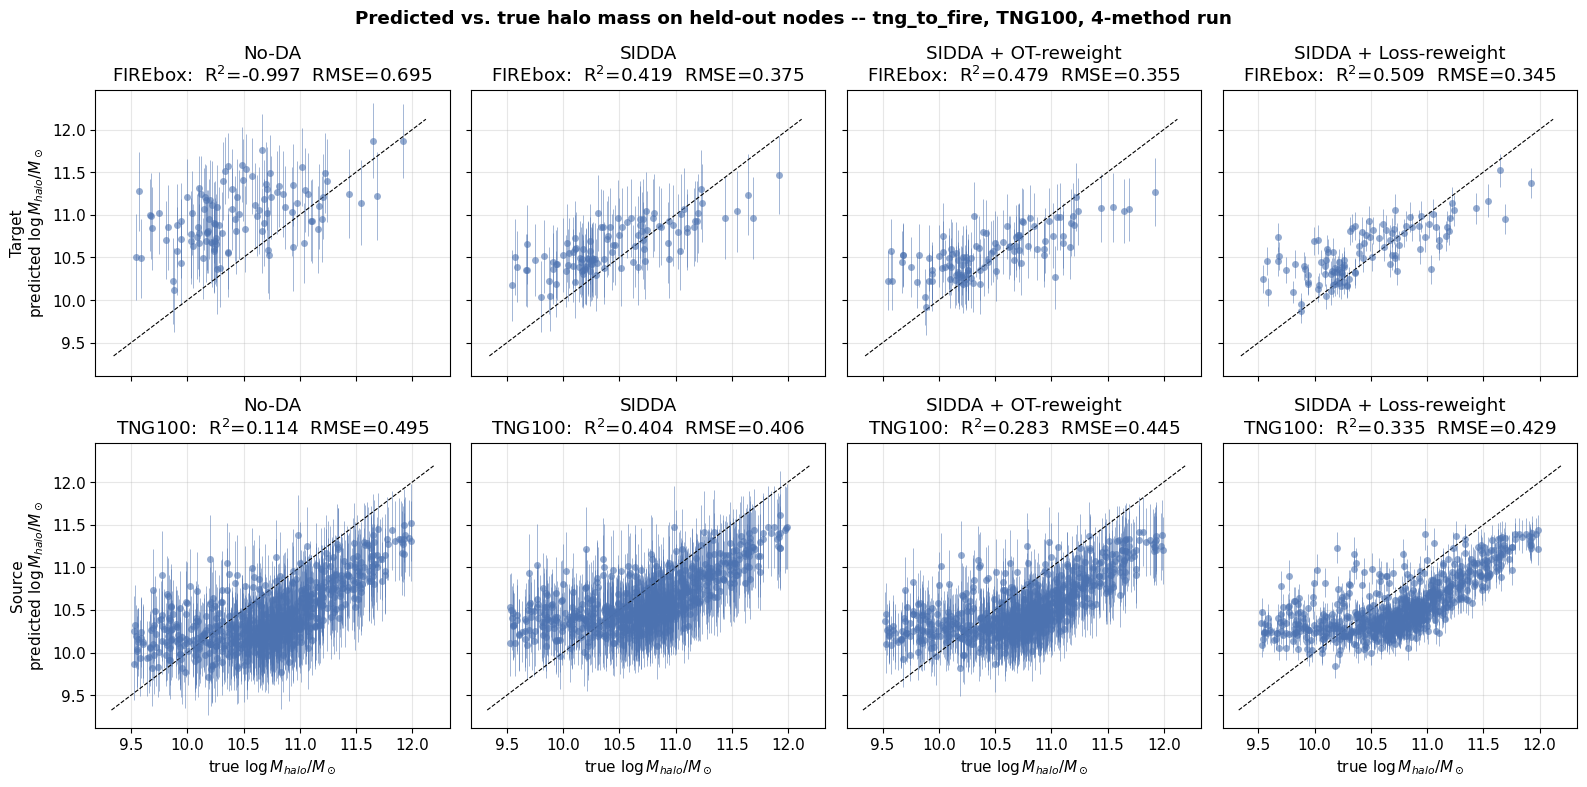

In [22]:
from analysis.plot_style import plot_pred_vs_true_with_uncertainty

for direction, spec in DIRECTIONS.items():
    fig, axes = plt.subplots(2, len(ALL_METHOD_ORDER), figsize=(16, 8), sharex=True, sharey=True)

    for col, label in enumerate(ALL_METHOD_ORDER):
        preds = predictions_all[direction][label]
        r = results_all[direction][label]
        for row, domain in enumerate(["tgt", "src"]):
            dom_name = spec["tgt_name"] if domain == "tgt" else spec["src_name"]
            true, mean, std = preds[domain]
            ax = axes[row, col]
            plot_pred_vs_true_with_uncertainty(
                true, mean, std, ax,
                r2=r[domain]["r2"], rmse=r[domain]["rmse"],
                title=f"{label}\n{dom_name}:  R$^2$={r[domain]['r2']:.3f}  RMSE={r[domain]['rmse']:.3f}",
            )
            if col == 0:
                ax.set_ylabel(("Target" if row == 0 else "Source") + "\npredicted $\\log M_{halo}/M_\\odot$")
            if row == 1:
                ax.set_xlabel("true $\\log M_{halo}/M_\\odot$")

    plt.suptitle(f"Predicted vs. true halo mass on held-out nodes -- {direction}, TNG100, 4-method run",
                 fontweight="bold")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"tng100_4methods_{direction}_pred_scatter.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"saved {fig_path}")
    plt.show()


## Pull distributions

`pull = (pred_mean - true) / pred_std`. A well-calibrated model gives pulls
distributed as `N(0, 1)`: the black dashed curve is that reference, the
colored curve is a Gaussian fit (`mu`, `sigma`) to the actual pulls, and the
title's `chi^2 = mean(pull**2) = mu**2 + sigma**2` is the single-number
summary reported in the table above.

saved D:\Minerva\Senior Year\Capstone\DM_FIREbox_notebook_created_snapshot\output\domain-shift-tng100\tng100_4methods_tng_to_fire_pulls.png


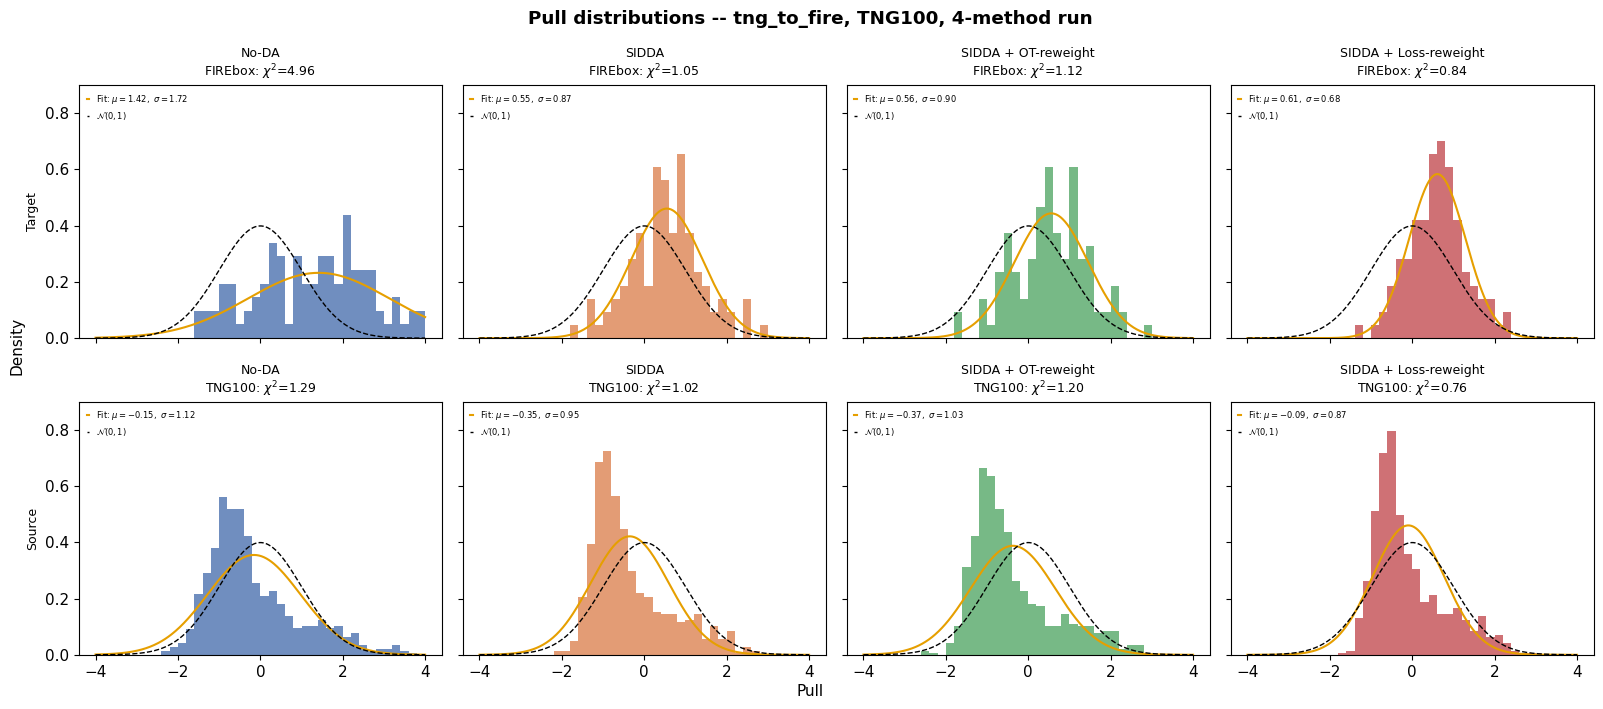

In [16]:
METHOD_COLORS = {
    "No-DA": "#4C72B0",
    "SIDDA": "#DD8452",
    "SIDDA + OT-reweight": "#55A868",
    "SIDDA + Loss-reweight": "#C44E52",
}
CB_BLACK = "#000000"

bin_edges = np.linspace(-4, 4, 41)
x_grid = np.linspace(-4, 4, 400)

for direction, spec in DIRECTIONS.items():
    fig, axes = plt.subplots(2, len(ALL_METHOD_ORDER), figsize=(16, 7), sharex=True, sharey=True)

    for col, label in enumerate(ALL_METHOD_ORDER):
        preds = predictions_all[direction][label]
        color = METHOD_COLORS[label]
        for row, domain in enumerate(["tgt", "src"]):
            dom_name = spec["tgt_name"] if domain == "tgt" else spec["src_name"]
            true, mean, std = preds[domain]
            _, chi2, pulls = compute_eps_chi2(true, mean, std)

            ax = axes[row, col]
            ax.hist(pulls, bins=bin_edges, density=True, alpha=0.8, color=color)

            mu, sigma = norm.fit(pulls)
            ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color="#E69F00", lw=1.5,
                    label=fr"Fit: $\mu={mu:.2f},\ \sigma={sigma:.2f}$")
            ax.plot(x_grid, norm.pdf(x_grid), color=CB_BLACK, lw=1, linestyle="--", label=r"$\mathcal{N}(0,1)$")

            ax.set_title(f"{label}\n{dom_name}: $\\chi^2$={chi2:.2f}", fontsize=9)
            ax.legend(fontsize=6, frameon=False, loc="upper left", handlelength=0.3)
            ax.grid(False)
            ax.set_ylim([0, 0.9])
            if col == 0:
                ax.set_ylabel("Target" if row == 0 else "Source", fontsize=9)

    fig.text(0.5, 0.0, "Pull", ha="center")
    fig.text(0.0, 0.5, "Density", va="center", rotation="vertical")
    plt.suptitle(f"Pull distributions -- {direction}, TNG100, 4-method run", fontweight="bold")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"tng100_4methods_{direction}_pulls.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"saved {fig_path}")
    plt.show()


## Isomap latent space, per direction: top row by domain, bottom row by halo mass

Uses the models trained above directly (no checkpoint reload needed --
they're already in memory in `trainers_all`). Isomap is fit jointly on
`[z_src; z_tgt]` per method so both domains share one embedding.

saved D:\Minerva\Senior Year\Capstone\DM_FIREbox_notebook_created_snapshot\output\domain-shift-tng100\tng100_4methods_tng_to_fire_isomap_latent.png


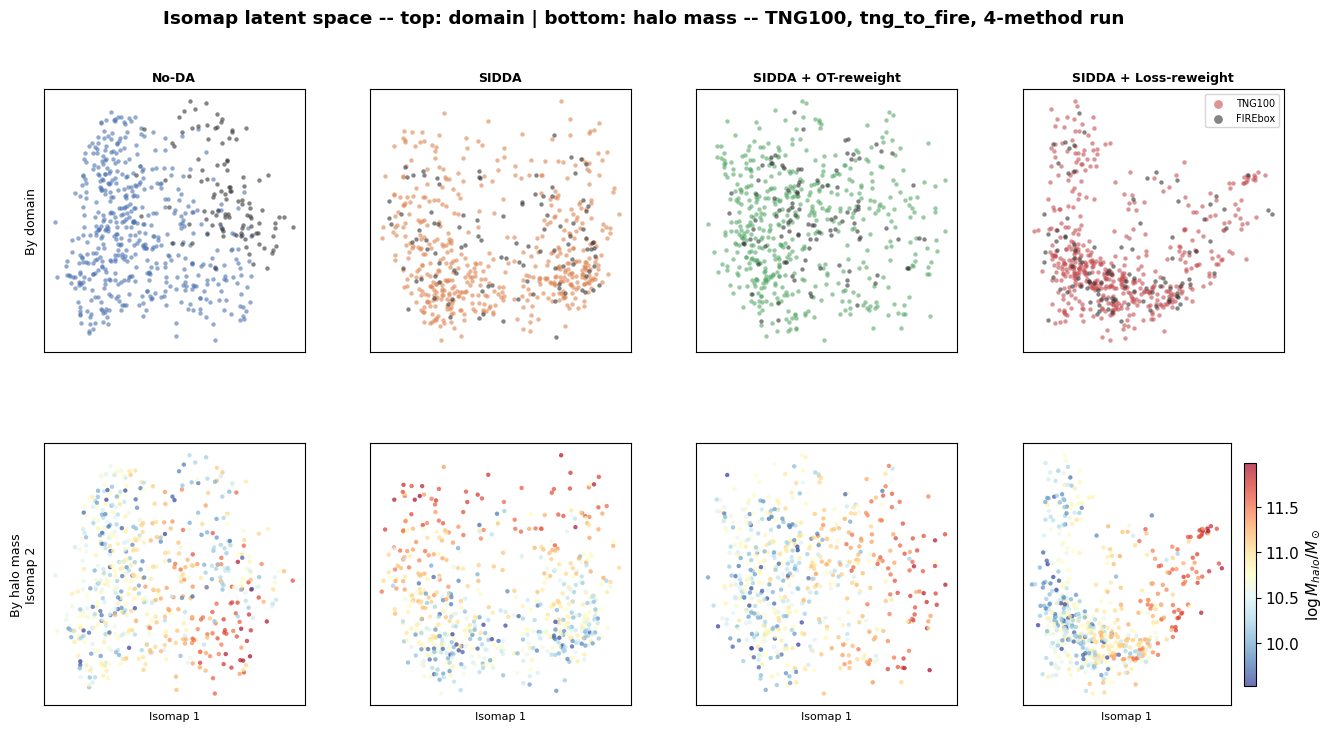

In [17]:
import matplotlib.gridspec as gridspec
from sklearn.manifold import Isomap

MAX_PLOT_NODES = 500
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]


@torch.no_grad()
def node_outputs(model, graph, mask_attr="test_mask", max_nodes=None, seed=42):
    '''Encode *graph* once and return (z, mean_pred, y) for its masked nodes only.'''
    device = next(model.parameters()).device
    model.eval()
    g = graph.to(device)
    idx = getattr(g, mask_attr).nonzero(as_tuple=False).view(-1)
    if max_nodes is not None and idx.numel() > max_nodes:
        gen = torch.Generator(device="cpu").manual_seed(seed)
        sel = torch.randperm(idx.numel(), generator=gen)[:max_nodes].to(idx.device)
        idx = idx[sel]
    z = model.encode(g)[idx]
    out = model.regress(z)
    mean_pred = out[..., 0] if out.dim() > 1 and out.size(-1) == 2 else out.view(-1)
    return z.cpu().numpy(), mean_pred.cpu().numpy(), g.y[idx].view(-1).cpu().numpy()


for direction, spec in DIRECTIONS.items():
    src, tgt = spec["src"], spec["tgt"]
    models = {label: trainers_all[direction][label].model for label in ALL_METHOD_ORDER}

    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(2, len(ALL_METHOD_ORDER), hspace=0.35, wspace=0.25)
    sc = None

    y_all = np.concatenate([
        node_outputs(next(iter(models.values())), g, "test_mask", MAX_PLOT_NODES)[2]
        for g in (src, tgt)
    ])
    vmin, vmax = float(y_all.min()), float(y_all.max())

    for col, label in enumerate(ALL_METHOD_ORDER):
        model = models[label]
        zs, _, ys = node_outputs(model, src, "test_mask", MAX_PLOT_NODES)
        zt, _, yt = node_outputs(model, tgt, "test_mask", MAX_PLOT_NODES)

        z_all = np.vstack([zs, zt])
        n_nb = int(min(15, max(2, len(z_all) - 1)))
        z2d = Isomap(n_components=2, n_neighbors=n_nb).fit_transform(z_all)
        zs2d, zt2d = z2d[:len(zs)], z2d[len(zs):]

        ax = fig.add_subplot(gs[0, col])
        ax.scatter(zs2d[:, 0], zs2d[:, 1], s=10, alpha=0.6, color=COLORS[col], label=spec["src_name"], linewidths=0)
        ax.scatter(zt2d[:, 0], zt2d[:, 1], s=10, alpha=0.6, color="#333333", label=spec["tgt_name"], linewidths=0)
        ax.set_title(label, fontsize=9, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel("By domain", fontsize=9)
        if col == len(ALL_METHOD_ORDER) - 1:
            ax.legend(fontsize=7, markerscale=2, loc="best")

        ax2 = fig.add_subplot(gs[1, col])
        sc = ax2.scatter(z2d[:, 0], z2d[:, 1], c=np.concatenate([ys, yt]), cmap="RdYlBu_r", s=10, alpha=0.7,
                          vmin=vmin, vmax=vmax, linewidths=0)
        ax2.set_xticks([]); ax2.set_yticks([])
        ax2.set_xlabel("Isomap 1", fontsize=8)
        if col == 0:
            ax2.set_ylabel("By halo mass\nIsomap 2", fontsize=9)

    fig.colorbar(sc, ax=fig.axes[-1], label="$\\log M_{halo}/M_\\odot$", shrink=0.85)
    plt.suptitle(f"Isomap latent space -- top: domain | bottom: halo mass -- TNG100, {direction}, 4-method run",
                 fontweight="bold")
    fig_path = OUTPUT_DIR / f"tng100_4methods_{direction}_isomap_latent.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"saved {fig_path}")
    plt.show()
